In [46]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Imports

In [47]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torch.autograd import Variable
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import polars as pl
from typing import List, Tuple
from tqdm import tqdm
from sklearn.decomposition import PCA  
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
import importlib
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.preprocessing import LabelEncoder
import os
# custom files
import cvhelper
import model_helper
import rnn_helper
importlib.reload(cvhelper)
importlib.reload(model_helper)
importlib.reload(rnn_helper)

<module 'rnn_helper' from '/Users/virginiawang/Library/CloudStorage/OneDrive-Personal/Lab/Model/rnn_helper.py'>

In [48]:
# path to full dataset
data_path = './ISO_NP_full_dataset_Hz.parquet'
# region to filter
filter_region = 'Isocortex'
# save images in 
save_path = os.path.join(os.getcwd(), 'results', filter_region)
os.makedirs(save_path, exist_ok=True)

In [49]:
unique_regions = (
    pl.scan_parquet(data_path)
    .select("region_parent")
    .unique()
    .collect()
    .get_column("region_parent")
    .to_list()
)

print(unique_regions)
for region in unique_regions:
    df_polars = (
        pl.scan_parquet(data_path)
        .filter(pl.col("region_parent") == region)
        .select(["recording_name", "firing_rate_hz", "phase", "iso_conc%", "region_parent"])
        .collect()
    )
    print(f"{region}: {len(df_polars)} recordings")

['Thalamus', 'Hippocampus', 'Isocortex', 'Amygdala', 'Hypothalamus']
Thalamus: 883 recordings
Hippocampus: 53 recordings
Isocortex: 37 recordings
Amygdala: 16 recordings
Hypothalamus: 59 recordings


# Preprocess Data

In [50]:
df_final = rnn_helper.preprocess_anesthesia_data(data_path, region_name=filter_region)

print(f"df_final shape: {df_final.shape}")
print(f"Columns: {df_final.columns.tolist()}")

sample_firing_rates = df_final.iloc[0]['firing_rate_hz']
sample_phases = df_final.iloc[0]['phase'] 

print(f"Firing rate length: {len(sample_firing_rates)}")
print(f"Phase length: {len(sample_phases)}")
print(f"Phase sequence check:")
print(f"0-179s: {set(sample_phases[0:180])}")      # should be baseline
print(f"180-359s: {set(sample_phases[180:360])}")  # should be induction
print(f"360-539s: {set(sample_phases[360:540])}")  # should be maintenance
print(f"540-719s: {set(sample_phases[540:720])}")  # should be emergence

df_all_regions = rnn_helper.preprocess_anesthesia_data(data_path, region_name=None)


Processing 37 recordings for Isocortex...

PREPROCESSING COMPLETE
Original recordings: 37
Successfully processed: 37
df_final shape: (37, 5)
Columns: ['recording_name', 'firing_rate_hz', 'phase', 'region_parent', 'original_index']
Firing rate length: 720
Phase length: 720
Phase sequence check:
0-179s: {'baseline'}
180-359s: {'induction'}
360-539s: {'maintenance'}
540-719s: {'emergence'}
Processing 0 recordings for None...

PREPROCESSING COMPLETE
Original recordings: 0
Successfully processed: 0


/Users/virginiawang/Library/CloudStorage/OneDrive-Personal/Lab/Model/rnn_helper.py:57: UserWarning: Comparisons with None always result in null. Consider using `.is_null()` or `.is_not_null()`.
  df_polars = df_polars.filter(pl.col("region_parent") == region_name)


In [51]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [52]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


# Dataset Class

In [53]:
class AnesthesiaDataset(Dataset):
    def __init__(self, dataframe):
        """        
        Args:
            dataframe: pandas DataFrame with columns ['recording_name', 'firing_rate_hz', 'phase', 'region_parent']
        """
        # Process the data
        self.recordings = []
        self.labels = []
        self.dataframe = dataframe
        unique_phases = ['baseline', 'emergence', 'induction', 'maintenance']
        
        self.label_encoder = LabelEncoder()
        self.label_encoder.fit(unique_phases)
        self.phase_names = self.label_encoder.classes_
        self.num_classes = len(self.phase_names)
        
        # process the actual data
        for idx, row in self.dataframe.iterrows():
            firing_rates = row['firing_rate_hz']
            phases = row['phase']
            
            # Convert to numpy arrays 
            firing_rates = np.array(firing_rates, dtype=np.float32)
            
            # Clean phases - convert to string and filter out None values
            phases_clean = []
            firing_rates_clean = []
            
            for i, (fr, phase) in enumerate(zip(firing_rates, phases)):
                if phase is not None and not np.isnan(fr):
                    phases_clean.append(str(phase))
                    firing_rates_clean.append(fr)
            
            # Encode phase labels
            phase_encoded = self.label_encoder.transform(phases_clean)
            
            self.recordings.append(np.array(firing_rates_clean, dtype=np.float32))
            self.labels.append(phase_encoded)
                
        
        print(f"Successfully loaded {len(self.recordings)}")
        if len(self.recordings) > 0:
            print(f"Average recording length: {np.mean([len(r) for r in self.recordings]):.1f} seconds")
    
    def __len__(self):
        return len(self.recordings)
    
    def __getitem__(self, idx):
        return (
            torch.FloatTensor(self.recordings[idx]).unsqueeze(-1),  # Add feature dimension
            torch.LongTensor(self.labels[idx])
        )

# RNN with Attention for Phase Classification

In [54]:
class AttentionRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, num_classes=4, dropout=0.2):
        """        
        Args:
            input_size: number of input features (1: firing rate; 2: add iso_conc)
            hidden_size: size of LSTM hidden state
            num_layers: number of LSTM layers
            num_classes: number of phase classes
            dropout: dropout rate
        """
        super(AttentionRNN, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # Attention mech
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
        
        # classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes)
        )
        
    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        lstm_out, _ = self.lstm(x)  # (batch_size, seq_len, hidden_size)
        attention_weights = self.attention(lstm_out)  # (batch_size, seq_len, 1)
        attention_weights = torch.softmax(attention_weights, dim=1)  # sum to 1 
        output = self.classifier(lstm_out)  # (batch_size, seq_len, num_classes)
        
        return output, attention_weights.squeeze(-1)  # (batch_size, seq_len, num_classes), (batch_size, seq_len)
    

# Train Loop

In [55]:
def train_model(model, train_loader, val_loader, num_epochs=50, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss(ignore_index=0)  # Ignore padding
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5) # reduces the learning rate when a monitored metric stops improving 
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    model.to(device)
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_sequences, batch_labels, lengths in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            batch_sequences = batch_sequences.to(device)
            batch_labels = batch_labels.to(device)
            
            optimizer.zero_grad()
            
            # forward pass
            outputs, attention_weights = model(batch_sequences)
            
            # calc loss only for non-padded positions
            mask = torch.zeros_like(batch_labels, dtype=torch.bool)
            for i, length in enumerate(lengths):
                mask[i, :length] = True
            
            # reshape for loss calculation
            outputs_flat = outputs.view(-1, outputs.size(-1))
            labels_flat = batch_labels.view(-1)
            mask_flat = mask.view(-1)
            
            # apply mask (to ignore padding)
            outputs_masked = outputs_flat[mask_flat]
            labels_masked = labels_flat[mask_flat]
            
            loss = criterion(outputs_masked, labels_masked)
            loss.backward()
            
            # gradient clipping (limits how large the gradients can get during backpropagation by scaling them down if they're too big)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            train_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs_masked, 1)
            train_total += labels_masked.size(0)
            train_correct += (predicted == labels_masked).sum().item()
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch_sequences, batch_labels, lengths in val_loader:
                batch_sequences = batch_sequences.to(device)
                batch_labels = batch_labels.to(device)
                
                outputs, attention_weights = model(batch_sequences)
                
                # calculate loss only for non-padded positions
                mask = torch.zeros_like(batch_labels, dtype=torch.bool)
                for i, length in enumerate(lengths):
                    mask[i, :length] = True
                
                outputs_flat = outputs.view(-1, outputs.size(-1))
                labels_flat = batch_labels.view(-1)
                mask_flat = mask.view(-1)
                
                outputs_masked = outputs_flat[mask_flat]
                labels_masked = labels_flat[mask_flat]
                
                loss = criterion(outputs_masked, labels_masked)
                val_loss += loss.item()
                
                # calculate accuracy
                _, predicted = torch.max(outputs_masked, 1)
                val_total += labels_masked.size(0)
                val_correct += (predicted == labels_masked).sum().item()
        
        # metrics
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        scheduler.step(avg_val_loss)
        
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        print(f'Learning Rate: {optimizer.param_groups[0]["lr"]:.6f}')
        print('-' * 50)

        
    return train_losses, val_losses, train_accuracies, val_accuracies

# Main Loop

In [56]:
def main(df, save_path):
    print("Starting RNN...")
    print("=" * 70)
    
    # make dataset
    dataset = AnesthesiaDataset(df)
    
    # split data
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    # create data loaders
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=rnn_helper.collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=rnn_helper.collate_fn)
    
    print(f"Training set size: {len(train_dataset)}")
    print(f"Validation set size: {len(val_dataset)}")
    
    input_size = 1
    hidden_size = 64
    num_layers=2
    num_classes=dataset.num_classes
    dropout=0.2
    # Initialize model
    model = AttentionRNN(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_classes=num_classes,
        dropout=dropout
    )

    # training time
    train_losses, val_losses, train_accs, val_accs = train_model(
        model, train_loader, val_loader, 
        num_epochs=30, learning_rate=0.001
    )
    
    # plot training curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(train_accs, label='Train Accuracy')
    ax2.plot(val_accs, label='Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, f'train_val_loss_accuracy'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # visualize attention for a few examples
    for i in range(min(3, len(val_dataset))):
        print(f"\n{filter_region}: Visualizing attention for validation recording {i}")
        rnn_helper.visualize_attention(model, dataset, val_dataset.indices[i], save_path = save_path)
       # Save model and results
    save_path = os.path.join(save_path, f'anesthesia_model_{filter_region.lower()}.pth')
    torch.save({
        'model_state_dict': model.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accs,
        'val_accuracies': val_accs,
        'model_config': {
            'input_size': input_size,
            'hidden_size': hidden_size,
            'num_layers': num_layers,
            'num_classes': num_classes
        }
    }, save_path)
    return model, dataset, train_losses, val_losses

Starting RNN...
Successfully loaded 37
Average recording length: 720.0 seconds
Training set size: 29
Validation set size: 8


Epoch 1/30: 100%|██████████| 8/8 [00:00<00:00,  9.92it/s]


Epoch [1/30]
Train Loss: 1.3487, Train Acc: 25.03%
Val Loss: 1.3294, Val Acc: 25.00%
Learning Rate: 0.001000
--------------------------------------------------


Epoch 2/30: 100%|██████████| 8/8 [00:00<00:00,  9.87it/s]


Epoch [2/30]
Train Loss: 1.2949, Train Acc: 29.43%
Val Loss: 1.2620, Val Acc: 34.50%
Learning Rate: 0.001000
--------------------------------------------------


...

Epoch [28/30]
Train Loss: 0.7395, Train Acc: 50.39%
Val Loss: 1.0140, Val Acc: 38.16%
Learning Rate: 0.000125
--------------------------------------------------


Epoch 29/30: 100%|██████████| 8/8 [00:00<00:00,  9.87it/s]


Epoch [29/30]
Train Loss: 0.7563, Train Acc: 50.70%
Val Loss: 1.0107, Val Acc: 38.35%
Learning Rate: 0.000125
--------------------------------------------------


Epoch 30/30: 100%|██████████| 8/8 [00:00<00:00, 10.09it/s]


Epoch [30/30]
Train Loss: 0.7232, Train Acc: 50.84%
Val Loss: 1.0117, Val Acc: 38.47%
Learning Rate: 0.000125
--------------------------------------------------


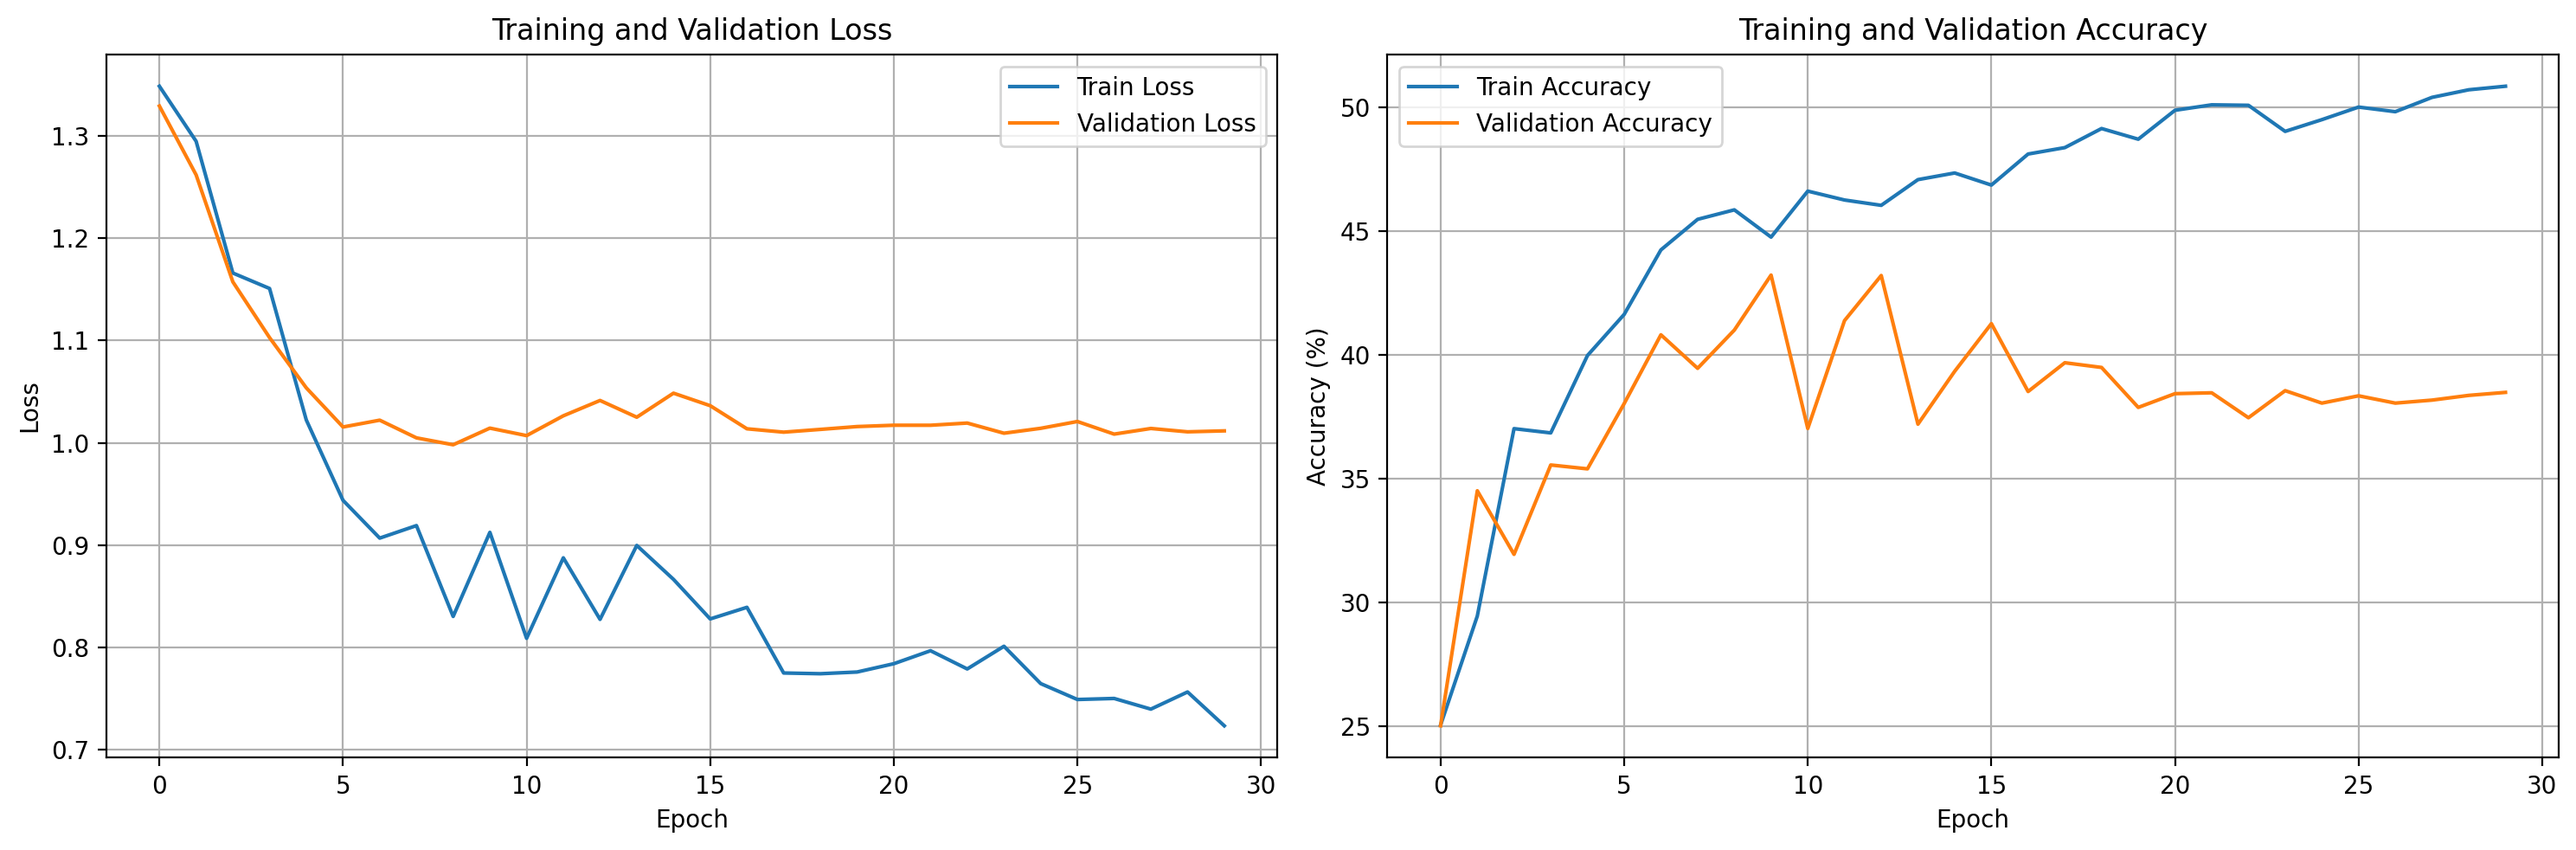


Isocortex: Visualizing attention for validation recording 0


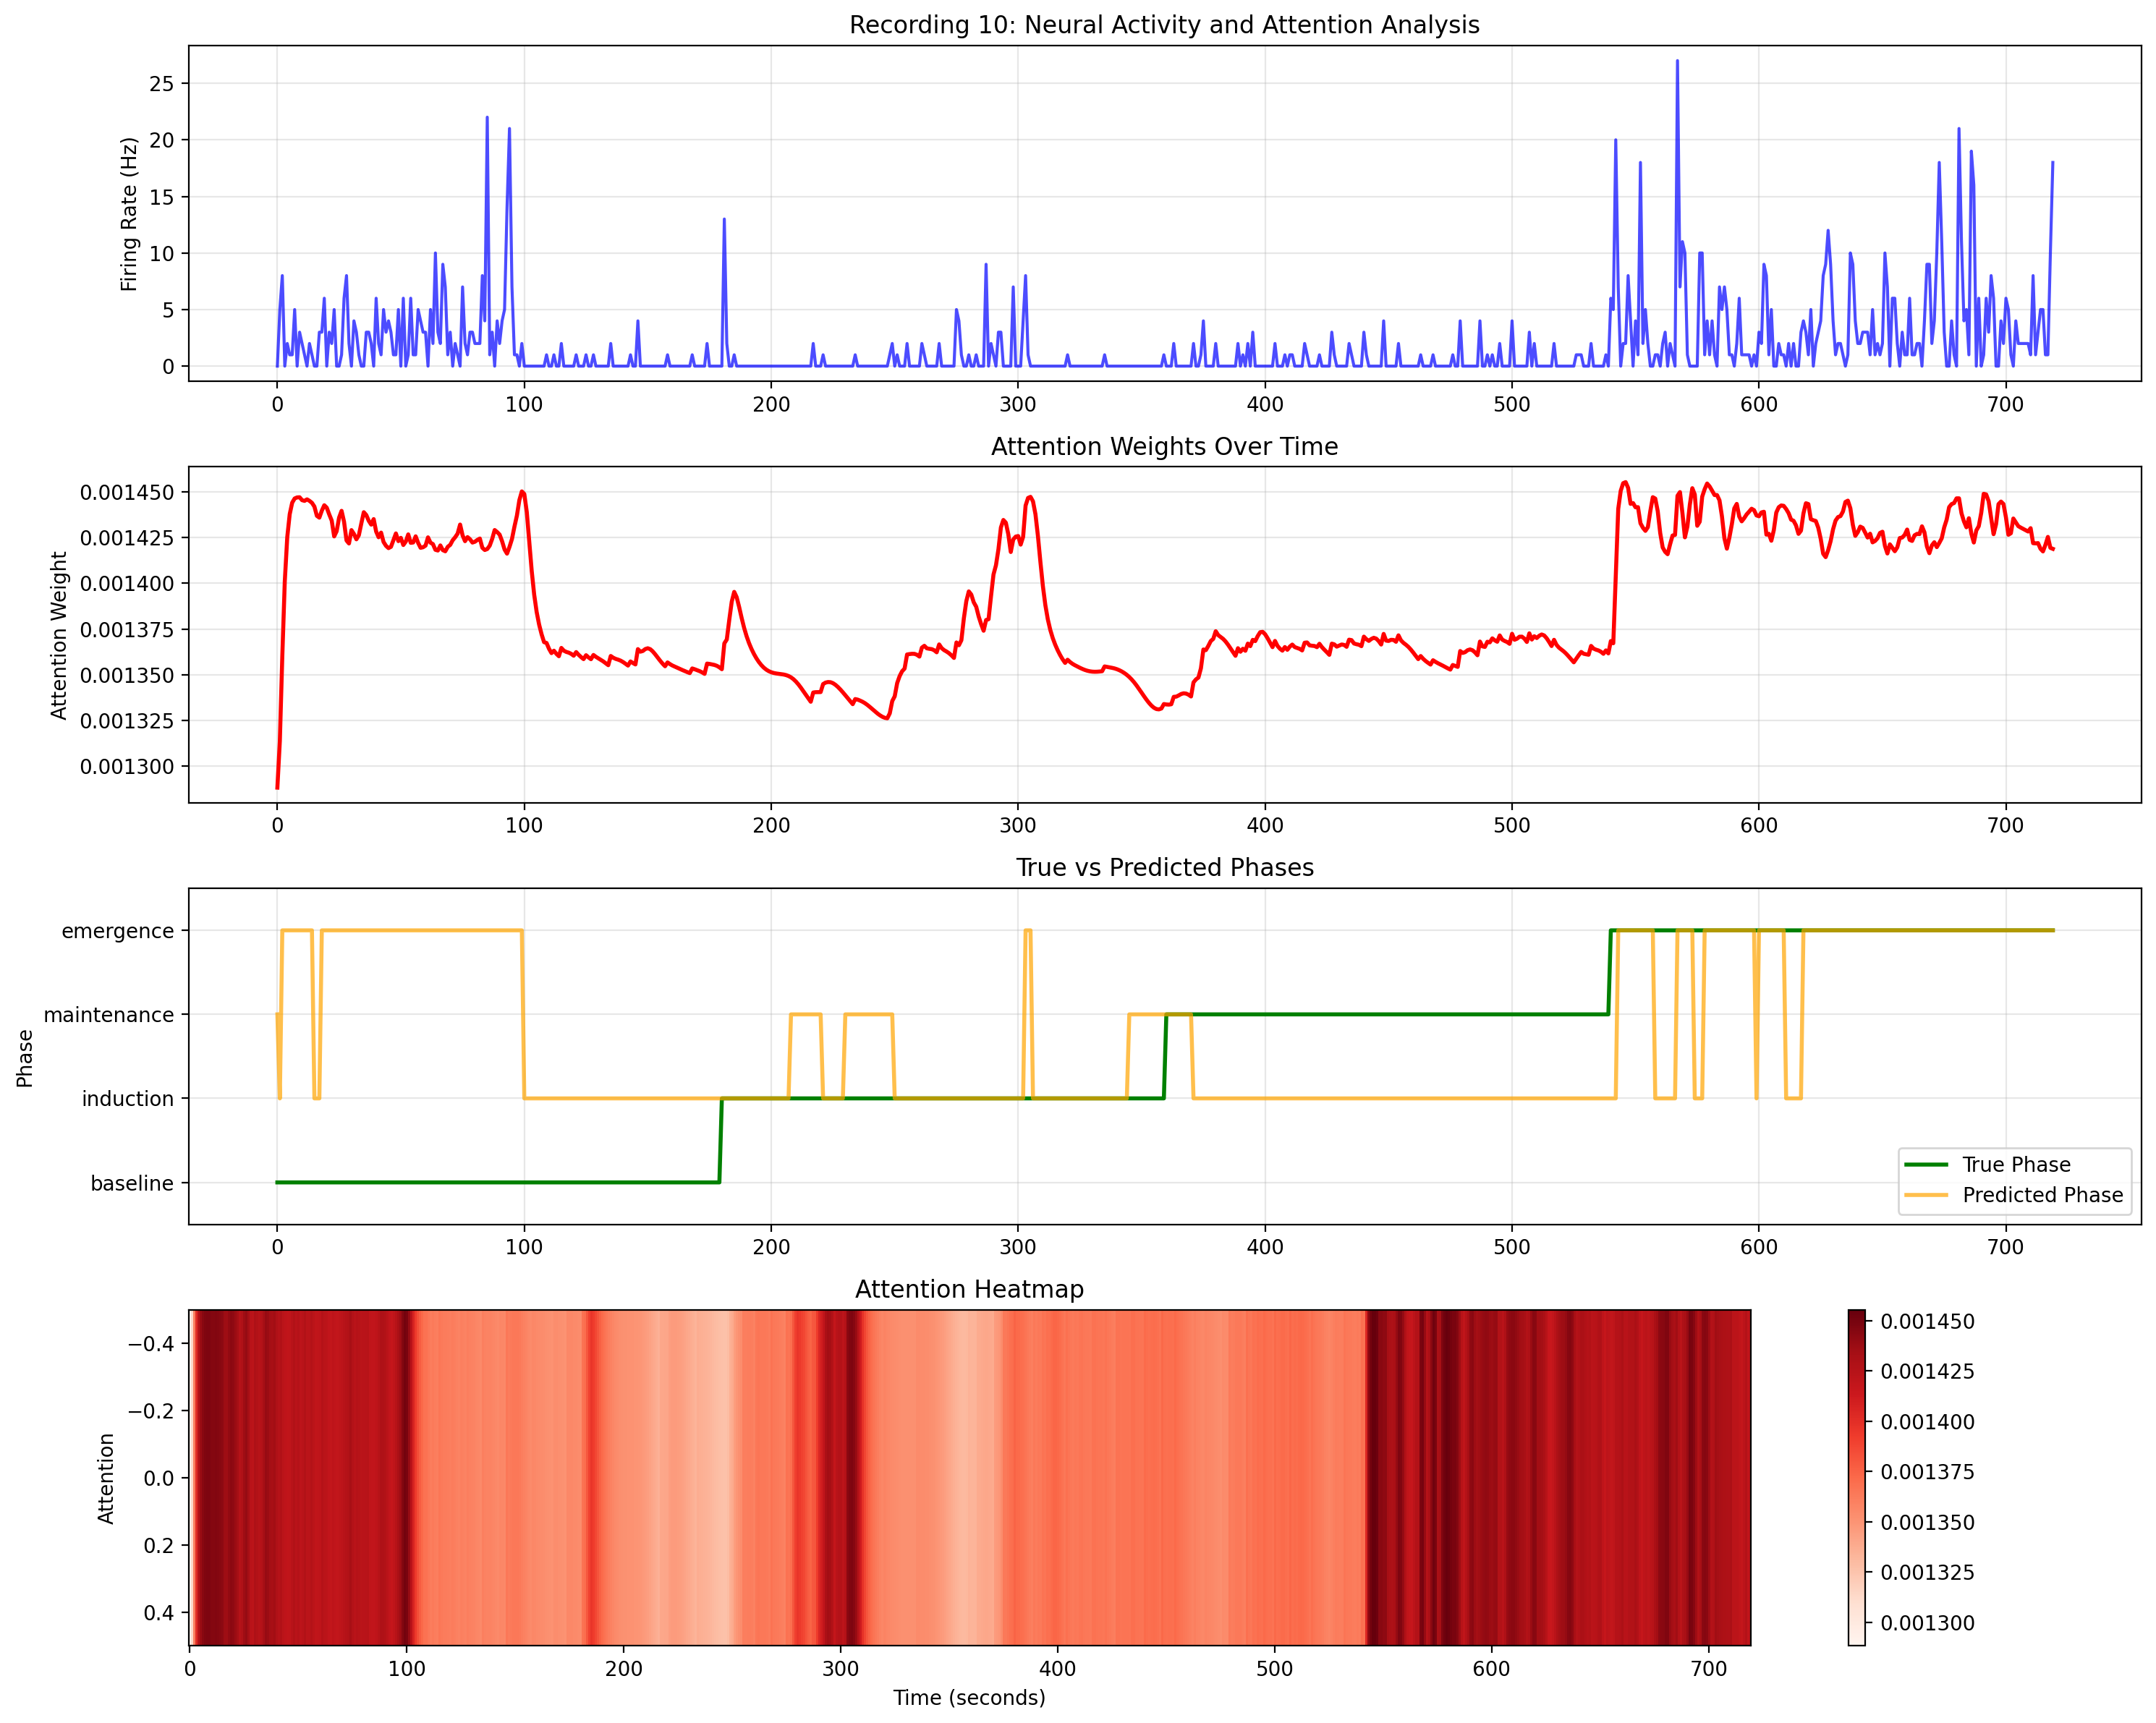


Isocortex: Visualizing attention for validation recording 1


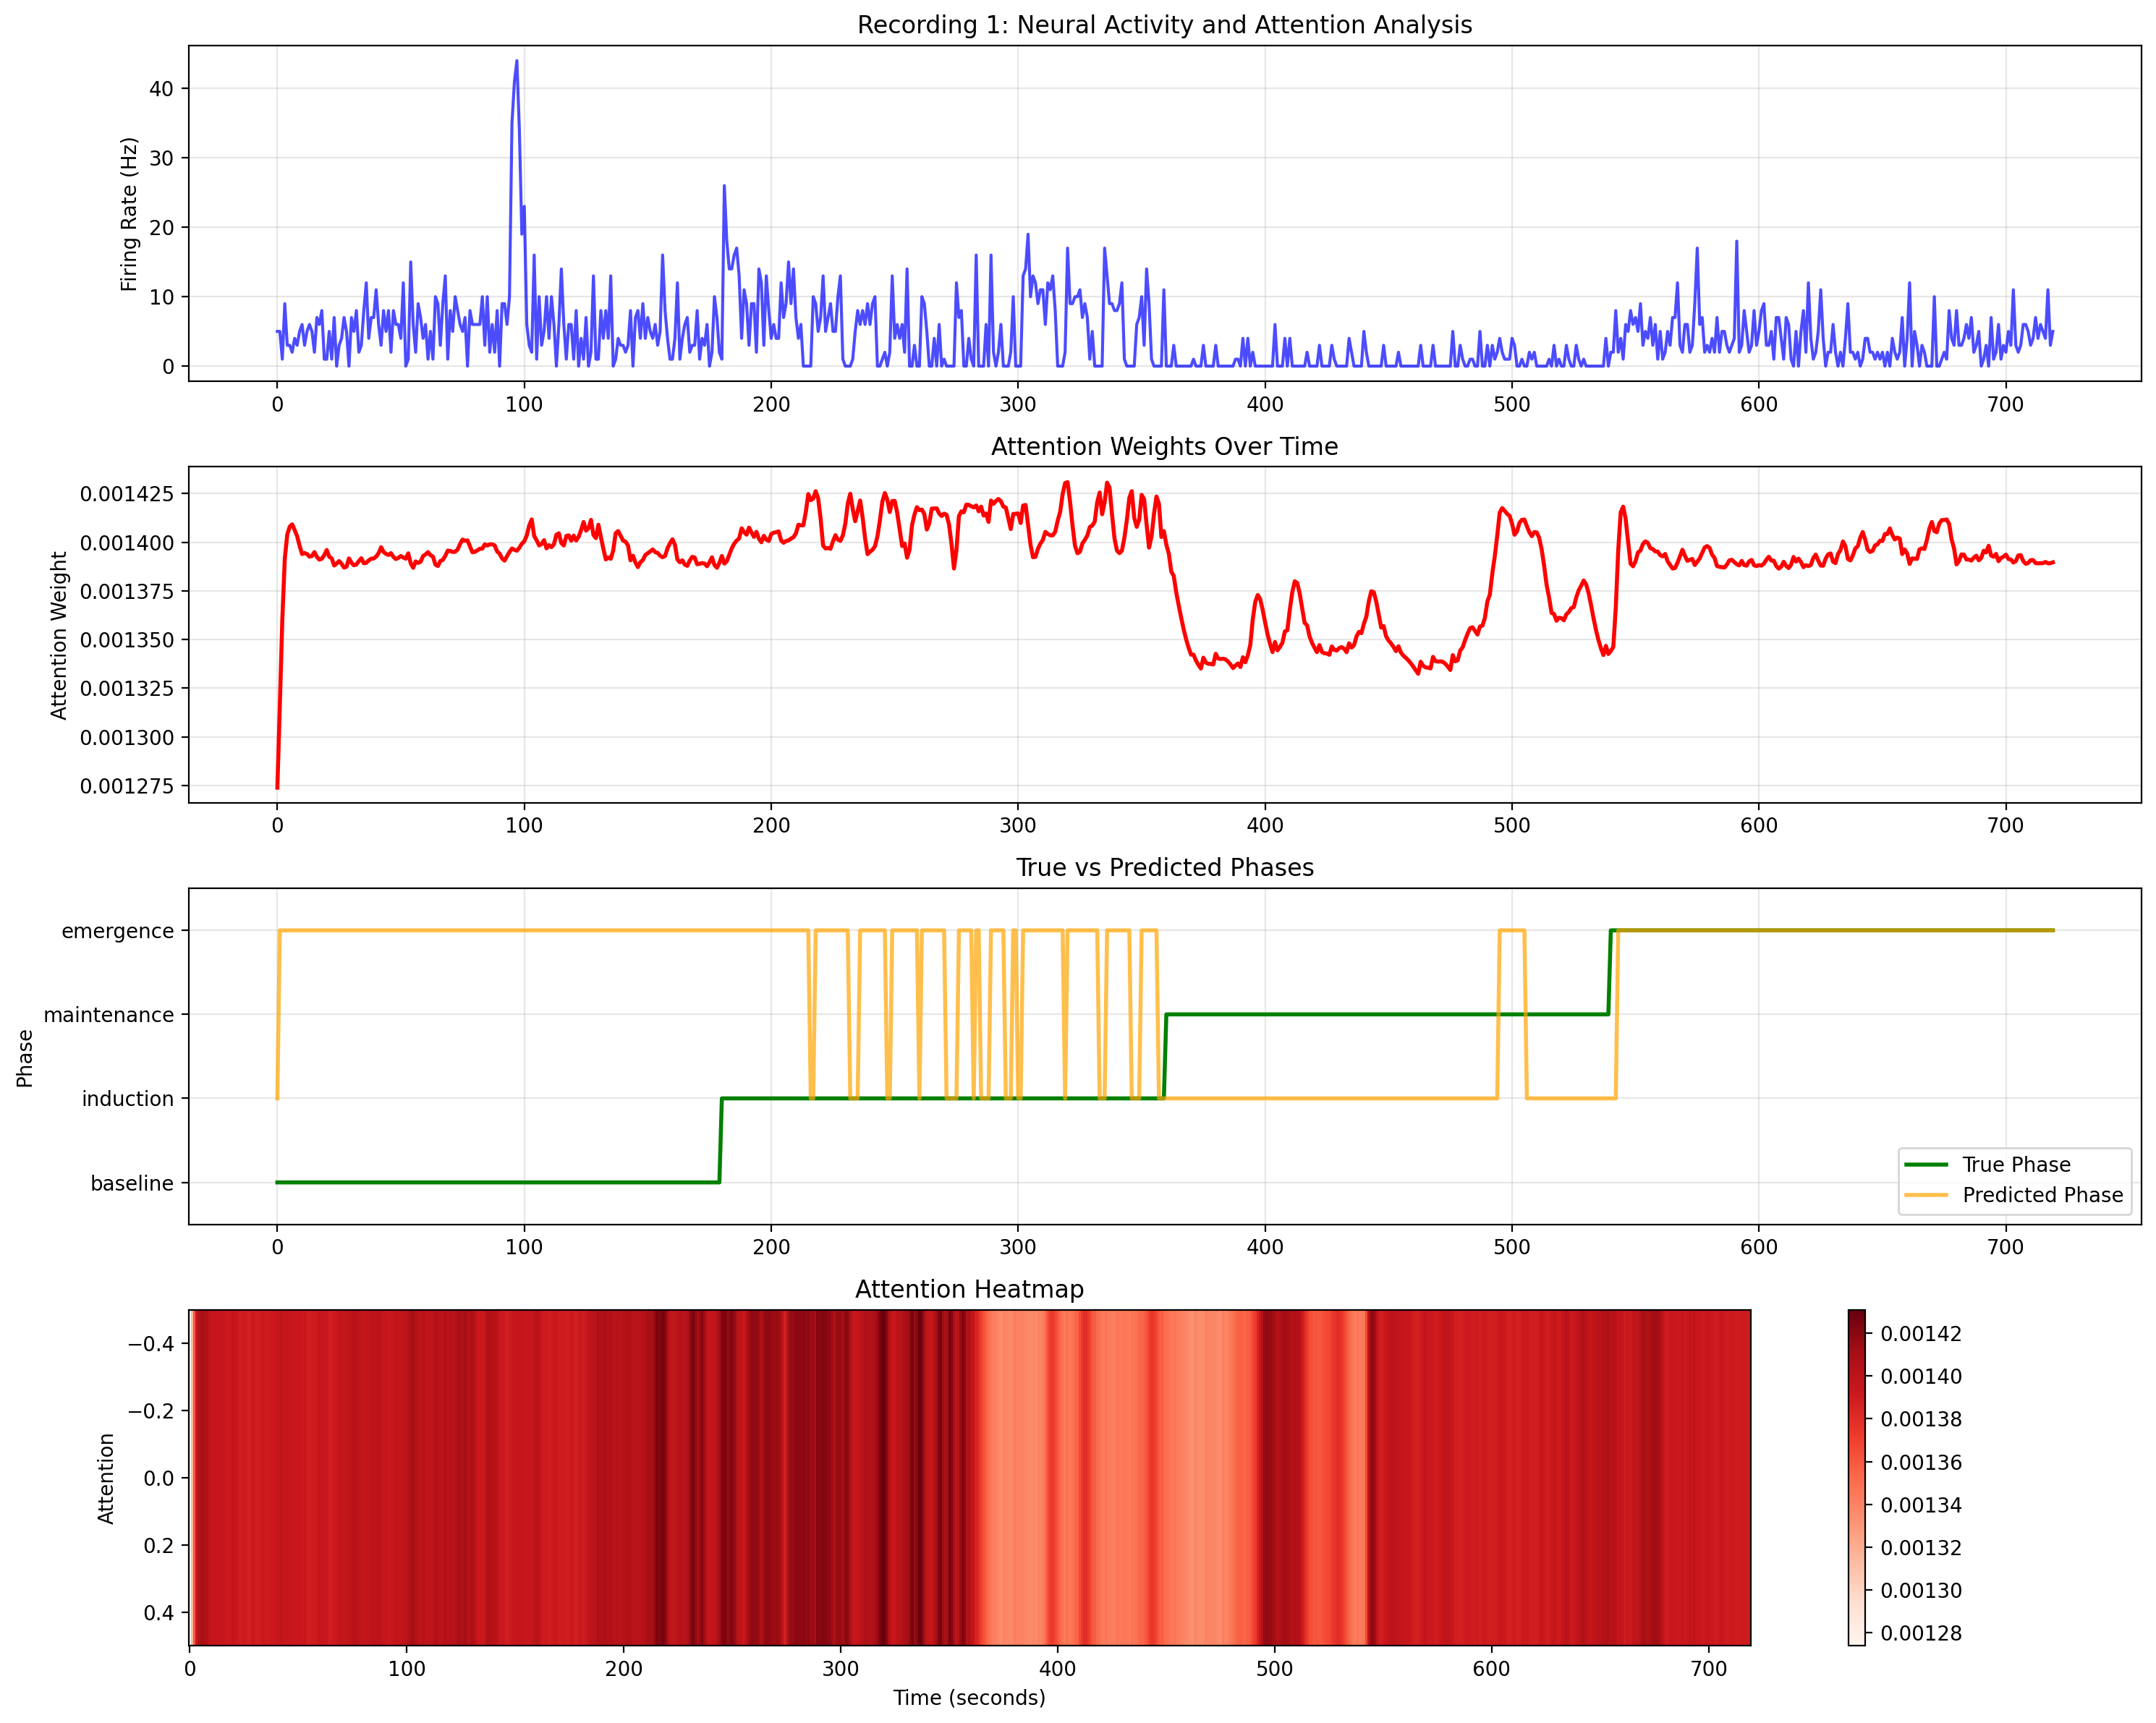


Isocortex: Visualizing attention for validation recording 2


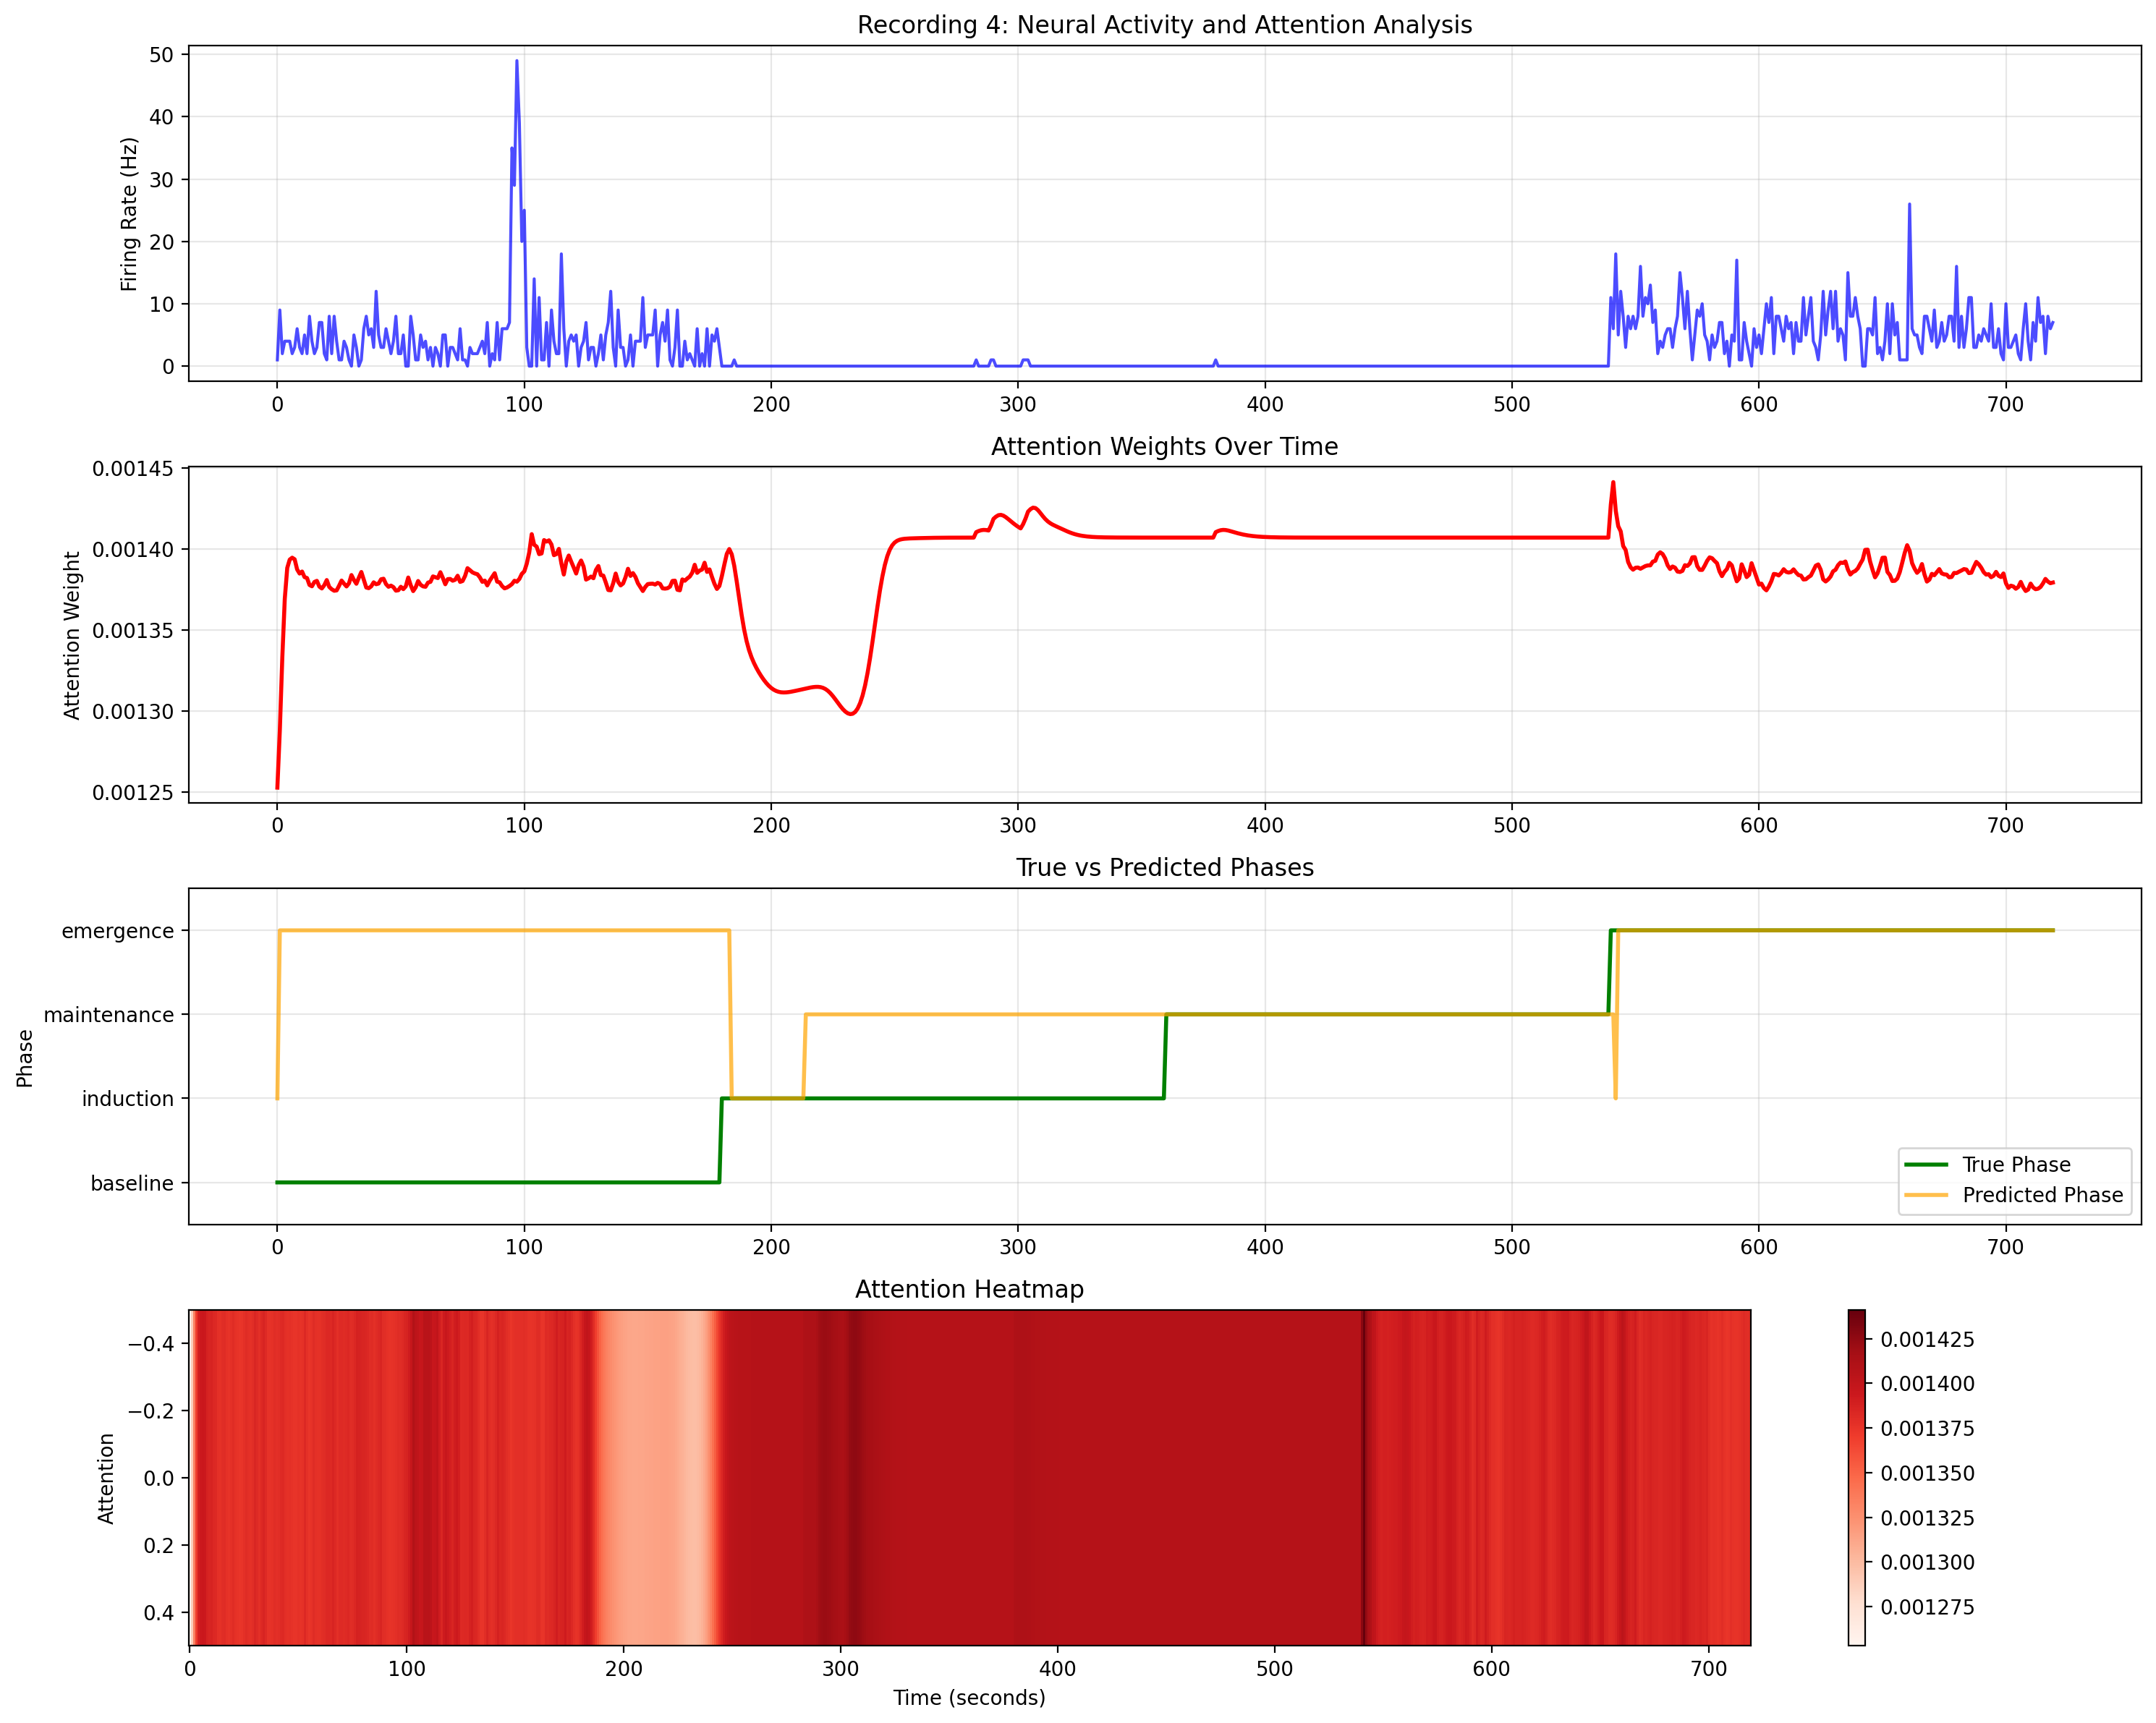

In [57]:
model, dataset, train_losses, val_losses = main(df_final, save_path)

In [58]:
# model, dataset, train_losses, val_losses = main(df_all_regions)

In [59]:
save_path

'/Users/virginiawang/Library/CloudStorage/OneDrive-Personal/Lab/Model/results/Isocortex'

thalamus keep track of subregions 

dont include baseline 

early vs late emergence

identify transition points - do both emergence.
anedotally, 3-4 minutes is when some kind of conciousness changes


there are cells that keep firing during induction/maintenance
separate units that do this, esp in thalamus (during training) 
cut off median or minimum of firing in maintenance
sort by maintenance activity (median firing rate or something similar; maybe average)
take off the top
*check that there is activity in baseline (average not lower than 0.5; 0.1)

maintainence: middle or late 

RMS 

